# Финальная часть исследования: BERTopic, sentiment и сетевые матрицы

## 0. Подготовка среды

In [1]:
#фикс совместимости
import inspect
from collections import namedtuple

if not hasattr(inspect, "getargspec"):
    ArgSpec = namedtuple("ArgSpec", "args varargs keywords defaults")
    def getargspec(func):
        fs = inspect.getfullargspec(func)
        return ArgSpec(fs.args, fs.varargs, fs.varkw, fs.defaults)
    inspect.getargspec = getargspec

In [2]:
#отключение gpu
import os

os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"

DEVICE = "cpu"
print("DEVICE:", DEVICE)

DEVICE: cpu


In [3]:
#установка зависимостей
INSTALL_DEPS = False

if INSTALL_DEPS:
    import sys
    import subprocess
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-U",
        "einops", "transformers<5", "sentence-transformers<5"
    ])

In [4]:
#импорты
import gc
import re
import time
import math
import string
import random
import warnings
from pathlib import Path
from itertools import combinations

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

try:
    pd.set_option("future.infer_string", False)
except Exception:
    pass

try:
    pd.options.mode.string_storage = "python"
except Exception:
    pass

import matplotlib.pyplot as plt

from tqdm.auto import tqdm
tqdm.pandas()

from stop_words import get_stop_words
from pymorphy3 import MorphAnalyzer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from scipy.stats import entropy

import torch
from transformers import pipeline, set_seed

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from umap import UMAP
import hdbscan
import networkx as nx

print("libraries loaded")
print("torch cuda available:", torch.cuda.is_available())

libraries loaded
torch cuda available: False


In [5]:
#настройки
DATA_DIR = "."
FILE_PART1 = os.path.join(DATA_DIR, "output_cursovaya_part1.xlsx")
FILE_PART2 = os.path.join(DATA_DIR, "output_cursovaya_part2.xlsx")

BASE_RESULTS_DIR = Path("results")
BASE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = BASE_RESULTS_DIR / "final_networks"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EMB_CACHE_DIR = BASE_RESULTS_DIR / "emb_cache"
EMB_CACHE_DIR.mkdir(parents=True, exist_ok=True)

GRAPH_DIR = OUTPUT_DIR / "graphs"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

MATRIX_DIR = OUTPUT_DIR / "matrices"
MATRIX_DIR.mkdir(parents=True, exist_ok=True)

LAG_DIR = OUTPUT_DIR / "lag_model"
LAG_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

FINAL_EMBEDDER_KEY = "giga_instruct"
FINAL_NR_TOPICS = 20
FINAL_TRAIN_SAMPLE = 100_000

FINAL_BERT_PARAMS = {
    "n_neighbors": 15,
    "n_components": 5,
    "min_dist": 0.0,
    "min_cluster_size": 30,
}

EMB_CACHE_TAG = "v2_giga_cluster_longctx"
EMBED_DOC_CHUNK = 2_000
TRANSFORM_CHUNK = 2_000

SENT_MODEL_NAME = "cointegrated/rubert-tiny-sentiment-balanced"
SENT_BATCH_SIZE = 64
SENT_THRESHOLD = 0.15

CHANNEL_TOPIC_MIN_SHARE = 0.01
CHANNEL_TOPIC_MIN_COUNT = 5
CHANNEL_GRAPH_TOP_K = 10
CHANNEL_GRAPH_MIN_WEIGHT = 0.05
TOPIC_GRAPH_TOP_K = 5
TOPIC_GRAPH_MIN_WEIGHT = 0.10

QUARTER_GRAPH_TOP_K = 10
QUARTER_GRAPH_MIN_ABS_WEIGHT = 0.01

EMBEDDING_CANDIDATES = {
    "giga_instruct": {
        "model_name": "ai-sage/Giga-Embeddings-instruct",
        "batch_size": 16,
        "max_seq_length": 1024,
        "trust_remote_code": True,
        "encode_kwargs": {
            "normalize_embeddings": True,
            "prompt": "Instruct: Определи основную тему и подтему телеграм-поста для тематической кластеризации\nQuery: ",
        },
    },
}

print("OUTPUT_DIR:", OUTPUT_DIR)
print("FINAL_BERT_PARAMS:", FINAL_BERT_PARAMS)
print("FINAL_NR_TOPICS:", FINAL_NR_TOPICS)
print("FINAL_TRAIN_SAMPLE:", FINAL_TRAIN_SAMPLE)

OUTPUT_DIR: results\final_networks
FINAL_BERT_PARAMS: {'n_neighbors': 15, 'n_components': 5, 'min_dist': 0.0, 'min_cluster_size': 30}
FINAL_NR_TOPICS: 20
FINAL_TRAIN_SAMPLE: 100000


## 1. Загрузка и базовая предобработка

In [6]:
#загрузка данных
def get_usecols(xlsx_path):
    cols = pd.read_excel(xlsx_path, nrows=0, engine="openpyxl").columns.tolist()
    needed = ["post_id", "message_id", "date", "channel_ref", "channel", "text"]
    return [c for c in needed if c in cols]

usecols_part1 = get_usecols(FILE_PART1)
usecols_part2 = get_usecols(FILE_PART2)
usecols = sorted(list(set(usecols_part1) | set(usecols_part2)))

df1 = pd.read_excel(FILE_PART1, usecols=usecols, engine="openpyxl")
df2 = pd.read_excel(FILE_PART2, usecols=usecols, engine="openpyxl")

df = pd.concat([df1, df2], ignore_index=True).drop_duplicates().reset_index(drop=True)
print(df.shape)
display(df.head())

(1093965, 4)


,channel,message_id,date,text
0,@RKadyrov_95,4361,2024-01-15 07:00:13+00:00,Сегодня рано утром сотрудники МВД России по Ше...
1,@RKadyrov_95,4362,2024-01-15 09:16:26+00:00,"Беспомощная ситуация жителей сектора Газа, кот..."
2,@RKadyrov_95,4363,2024-01-15 14:34:46+00:00,И снова группа «Аида» спецназа «АХМАТ» в работ...
3,@RKadyrov_95,4364,2024-01-16 08:25:50+00:00,Друзья! Сегодня многочисленные поздравления с ...
4,@RKadyrov_95,4365,2024-01-16 19:23:46+00:00,"Друзья! Проект, подготовленный и реализованный..."


In [7]:
#базовая очистка
def _series_to_pylist_safe(s):
    arr = getattr(getattr(s, "array", None), "_pa_array", None)
    if arr is not None:
        values = []
        for chunk in arr.iterchunks():
            values.extend(chunk.to_pylist())
        return values
    return list(s)

raw_text_values = _series_to_pylist_safe(df["text"])

keep_idx = []
text_values = []

for i, x in enumerate(raw_text_values):
    if x is None or pd.isna(x):
        continue
    x = str(x)
    if x.strip() == "":
        continue
    keep_idx.append(i)
    text_values.append(x)

df = df.iloc[keep_idx].copy().reset_index(drop=True)
df["text"] = pd.Series(np.asarray(text_values, dtype=object), dtype=object)

if "channel_ref" not in df.columns:
    if "channel" in df.columns:
        raw_channel_values = _series_to_pylist_safe(df["channel"])
        channel_values = [str(x) if x is not None and not pd.isna(x) else "unknown_channel" for x in raw_channel_values]
    else:
        channel_values = ["unknown_channel"] * len(df)
else:
    raw_channel_values = _series_to_pylist_safe(df["channel_ref"])
    channel_values = [str(x) if x is not None and not pd.isna(x) else "unknown_channel" for x in raw_channel_values]

df["channel_ref"] = pd.Series(np.asarray(channel_values, dtype=object), dtype=object)
df["channel_ref"] = df["channel_ref"].astype("category")

def _normalize_spaces(text):
    return re.sub(r"\s+", " ", text).strip()

df["text_raw"] = pd.Series(np.asarray([_normalize_spaces(x) for x in text_values], dtype=object), dtype=object)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.reset_index(drop=True)
df["doc_id"] = np.arange(len(df), dtype=np.int64)

print(df[["doc_id", "channel_ref", "date", "text_raw"]].head())

   doc_id   channel_ref                      date  \
0       0  @RKadyrov_95 2024-01-15 07:00:13+00:00   
1       1  @RKadyrov_95 2024-01-15 09:16:26+00:00   
2       2  @RKadyrov_95 2024-01-15 14:34:46+00:00   
3       3  @RKadyrov_95 2024-01-16 08:25:50+00:00   
4       4  @RKadyrov_95 2024-01-16 19:23:46+00:00   

                                            text_raw  
0  Сегодня рано утром сотрудники МВД России по Ше...  
1  Беспомощная ситуация жителей сектора Газа, кот...  
2  И снова группа «Аида» спецназа «АХМАТ» в работ...  
3  Друзья! Сегодня многочисленные поздравления с ...  
4  Друзья! Проект, подготовленный и реализованный...  


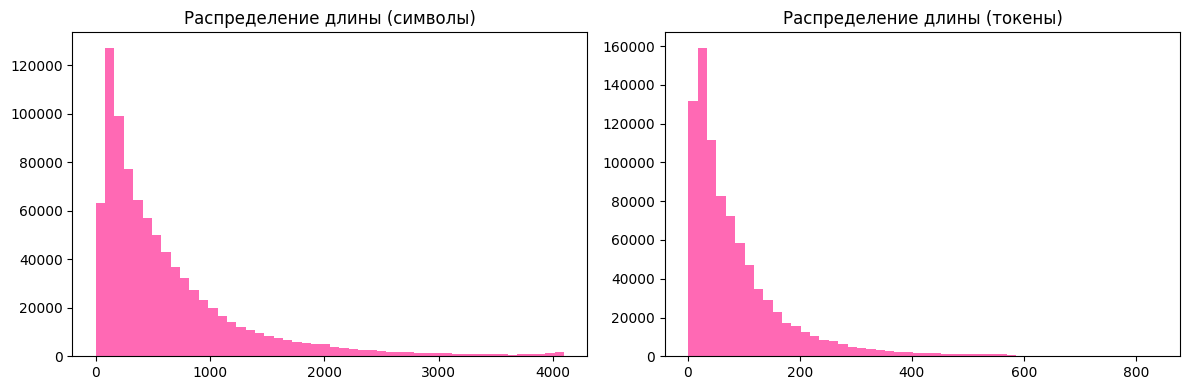

In [8]:
#длины текстов
text_raw_values = list(df["text_raw"])

df["len_chars"] = pd.Series(np.asarray([len(x) for x in text_raw_values], dtype=np.int32), dtype=np.int32)
df["len_tokens_raw"] = pd.Series(np.asarray([len(x.split()) for x in text_raw_values], dtype=np.int32), dtype=np.int32)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["len_chars"], bins=50, color="hotpink")
axes[0].set_title("Распределение длины (символы)")
axes[1].hist(df["len_tokens_raw"], bins=50, color="hotpink")
axes[1].set_title("Распределение длины (токены)")
plt.tight_layout()
plt.show()

## 2. Очистка текстов

In [9]:
#стоп-слова и очистка
stop_ru = set(get_stop_words("russian"))
stop_en = set(get_stop_words("english"))

custom_stop = {
    "канал", "канале", "каналу", "каналом", "каналы",
    "подписаться", "подписка", "подписывайтесь", "подпишись", "подпишитесь",
    "telegram", "телеграм", "телеграмм",
    "смотреть", "смотрите", "посмотреть",
    "читать", "читайте",
    "новость", "новости",
    "видео", "эфир", "эфире", "стрим", "трансляция", "live",
    "репост", "переслать", "поделиться",
    "rutube", "рутуб", "пул", "max",
}

topic_noise_stop = {
    "заявить", "сообщить", "сказать", "который", "очень", "вообще", "никто", "никакой",
    "сегодня", "вчера", "завтра", "просто", "это", "весь", "ещё", "также",
    "будьте", "находитесь", "улице", "помещениях", "окон",

    "детей", "дети", "ребенка", "ребёнка", "человека", "человек", "людей", "люди",
    "возможности", "возможность", "условиях", "условия", "условии",
    "например", "рассказал", "рассказала", "стало", "данные", "нового", "новый",
    "работы", "работа", "средств", "средства", "движения", "движение",
    "рост", "частных", "центра", "округе", "районах", "районах населенных",
    "некоторых", "основное", "временно", "объединений", "проживающих", "гражданства",
    "ситуацию", "ситуация", "версия", "ответить", "встреча", "рассказать",

    "instagram", "youtube", "whatsapp", "google", "meta", "vpn", "wifi",
    "cnn", "reuters", "bloomberg", "fox", "telegraph", "wsj", "nyt", "abc", "newsweek",
    "politico", "journal", "times", "post", "social", "digital", "business", "national",
    "axios", "arabiya", "unherd", "pais", "bild", "oracle", "apple", "tesla",
    "svt", "lrt", "dpa", "corp", "online", "week", "report", "data", "info",

    "tmervvoenkor", "rua", "engblueskywhatsapp", "xix", "shot", "baza", "upd", "zergulio",
    "boosty", "sponsr", "metametrica", "izru", "mash", "mashru", "ura", "rtvi", "вчк-огпу",

    "бпла", "всу", "сво", "рф", "сша", "ес", "оон", "мвд", "фбр", "мтс",
    "млн", "млрд", "трлн", "руб", "рублей", "долларов", "доллара", "евро",
    "года", "году", "лет", "год", "месяц", "день", "дней",

    "области", "область", "районе", "район", "городе", "города", "страны", "страна",
    "территории", "территорией", "территория", "окрестности", "округе",
    "взрыв", "взрывы", "поражены", "восстановлено", "боевых", "боевые",
    "серия", "анализ", "построили", "должность", "производства", "освобождение",
    "подразделений", "подразделения", "компаний", "российского", "специальной",
    "специальной военной", "военной", "народной", "населенных", "населенных пунктов",

    "герань", "герани", "гербера", "герберы", "умпк", "fpv", "отрк", "himars",
    "atacms", "storm", "shadow", "patriot", "nasams", "thaad", "tomahawk",
    "баба", "яга", "баба-яга", "патч", "патч-антенна",

    "проверяйте", "убедитесь", "ориентировочно", "номер", "класс",
    "девочка", "животных", "наушники", "авокадо", "роботы", "деревьев", "доски",
    "мафия", "коррупция", "мусора", "красная", "тихий", "горя", "плохие",
}

stopwords_all = stop_ru | stop_en | custom_stop
vectorizer_stopwords = stopwords_all | topic_noise_stop

punct = set(string.punctuation + '\u00ab\u00bb\u2014\u2026\u201c\u201d\u0060\u2018\u2019\u2013')
morph = MorphAnalyzer(lang="ru")

def preprocess_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|@\S+|#\S+", " ", text)
    text = re.sub(r"[^a-zа-яё\d\s-]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stopwords_all and t not in punct and len(t) > 2 and not t.isdigit()]
    lemmas = [morph.parse(t)[0].normal_form for t in tokens]
    return " ".join(lemmas)

def preprocess_text_bert(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|@\S+|#\S+", " ", text)
    text = re.sub(r"\bподпиш(?:ись|итесь|ись)\b", " ", text)
    text = re.sub(r"\btelegram\b|\bтелеграм(?:м)?\b|\brutube\b|\bрутуб\b", " ", text)
    text = re.sub(r"\b(?:instagram|youtube|whatsapp|google|meta|vpn|wifi|cnn|reuters|bloomberg|fox|telegraph|wsj|nyt|abc|newsweek|politico)\b", " ", text)
    text = re.sub(r"\b(?:tmervvoenkor|rua|engblueskywhatsapp|xix|shot|baza|upd|zergulio|boosty|sponsr|metametrica|izru|mash)\b", " ", text)
    text = re.sub(r"\b(?:млн|млрд|трлн|руб|рублей|долларов|доллара|евро|бпла|всу|сво|рф|сша|ес|оон)\b", " ", text)
    text = re.sub(r"\b[a-z]{1,4}\b", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

print("Функции предобработки готовы.")

Функции предобработки готовы.


In [10]:
#предобработка корпуса
def parallel_apply(series, func, n_jobs=1):
    values = list(series)
    return pd.Series(
        np.asarray([func(x) for x in tqdm(values)], dtype=object),
        index=series.index,
        dtype=object,
    )

def preprocess_text_embed(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\S+|#\S+", " ", text)
    text = re.sub(r"\bподпиш(?:ись|итесь|ись)\b", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_clean"] = parallel_apply(df["text_raw"], preprocess_text)
df["text_clean_bert"] = parallel_apply(df["text_raw"], preprocess_text_bert)
df["text_embed"] = parallel_apply(df["text_raw"], preprocess_text_embed)

df["len_tokens_clean"] = pd.Series(
    np.asarray([len(x.split()) for x in df["text_clean"]], dtype=np.int32),
    dtype=np.int32,
)
df["len_tokens_clean_bert"] = pd.Series(
    np.asarray([len(x.split()) for x in df["text_clean_bert"]], dtype=np.int32),
    dtype=np.int32,
)
df["len_tokens_embed"] = pd.Series(
    np.asarray([len(x.split()) for x in df["text_embed"]], dtype=np.int32),
    dtype=np.int32,
)

before = len(df)
df = df[
    (df["len_tokens_clean"] > 3)
    & (df["len_tokens_clean_bert"] > 3)
    & (df["len_tokens_embed"] > 3)
].reset_index(drop=True)

df["doc_id"] = np.arange(len(df), dtype=np.int64)
print(f"Документов после фильтрации: {len(df):,} (убрано {before - len(df):,})")

  0%|          | 0/866129 [00:00<?, ?it/s]

  0%|          | 0/866129 [00:00<?, ?it/s]

  0%|          | 0/866129 [00:00<?, ?it/s]

Документов после фильтрации: 847,684 (убрано 18,445)


## 3. Финальная BERTopic-модель

Используем выбранную конфигурацию: `giga_instruct`, `n_neighbors=15`, `n_components=5`, `min_dist=0.0`, `min_cluster_size=30`, редукция до 20 тем.

Модель обучается на репрезентативной подвыборке, а затем применяется ко всему корпусу через `transform`.

In [11]:
#функции embeddings
def _load_embedding_model(embedder_cfg):
    model = SentenceTransformer(
        embedder_cfg["model_name"],
        device=DEVICE,
        trust_remote_code=embedder_cfg.get("trust_remote_code", False),
    )
    model.max_seq_length = embedder_cfg.get("max_seq_length", 256)
    return model

def _build_vectorizer(fallback=False):
    return CountVectorizer(
        stop_words=list(vectorizer_stopwords),
        ngram_range=(1, 2),
        min_df=1 if fallback else 3,
        max_df=1.0 if fallback else 0.85,
        token_pattern=r"(?u)\b[а-яА-ЯёЁ][а-яА-ЯёЁ\-]{2,}\b",
    )

def _is_vectorizer_df_error(e):
    return "max_df corresponds to < documents than min_df" in str(e)

def _embedding_cache_path(prefix, embedder_key, n_docs):
    return EMB_CACHE_DIR / f"embeddings_{prefix}_{EMB_CACHE_TAG}_{embedder_key}_{int(n_docs)}.npy"

def _embedding_chunk_cache_path(prefix, embedder_key, n_docs, start, end):
    return EMB_CACHE_DIR / f"embeddings_{prefix}_{EMB_CACHE_TAG}_{embedder_key}_{int(n_docs)}_{int(start)}_{int(end)}.npy"

def _encode_docs_to_cache(prefix, embedder_key, embedder_cfg, docs):
    final_cache = _embedding_cache_path(prefix, embedder_key, len(docs))
    if final_cache.exists():
        print("load embeddings:", final_cache.name)
        return np.load(final_cache)

    model = _load_embedding_model(embedder_cfg)
    encode_kwargs = {
        "show_progress_bar": True,
        "batch_size": embedder_cfg.get("batch_size", 16),
        **embedder_cfg.get("encode_kwargs", {}),
    }

    chunks = []
    try:
        for start in range(0, len(docs), EMBED_DOC_CHUNK):
            end = min(start + EMBED_DOC_CHUNK, len(docs))
            chunk_cache = _embedding_chunk_cache_path(prefix, embedder_key, len(docs), start, end)

            if chunk_cache.exists():
                emb_chunk = np.load(chunk_cache)
                print(f"{prefix} {start}:{end} -> cache")
            else:
                print(f"{prefix} {start}:{end} -> encode")
                emb_chunk = model.encode(docs[start:end], **encode_kwargs)
                emb_chunk = np.asarray(emb_chunk, dtype=np.float32)
                np.save(chunk_cache, emb_chunk)

            chunks.append(emb_chunk)

        emb = np.vstack(chunks)
        np.save(final_cache, emb)
    finally:
        del model
        gc.collect()

    return emb

def _get_or_encode_chunk(prefix, embedder_key, embedder_cfg, docs_chunk, n_docs, start, end, model_holder):
    chunk_cache = _embedding_chunk_cache_path(prefix, embedder_key, n_docs, start, end)

    if chunk_cache.exists():
        return np.load(chunk_cache)

    if model_holder.get("model") is None:
        model_holder["model"] = _load_embedding_model(embedder_cfg)

    encode_kwargs = {
        "show_progress_bar": False,
        "batch_size": embedder_cfg.get("batch_size", 16),
        **embedder_cfg.get("encode_kwargs", {}),
    }

    emb_chunk = model_holder["model"].encode(docs_chunk, **encode_kwargs)
    emb_chunk = np.asarray(emb_chunk, dtype=np.float32)
    np.save(chunk_cache, emb_chunk)
    return emb_chunk

In [14]:
#обработка ошибки vectorizer
def _is_vectorizer_error(e):
    msg = str(e)
    return (
        "max_df corresponds to < documents than min_df" in msg
        or "empty vocabulary" in msg
        or "After pruning, no terms remain" in msg
    )

In [21]:
#загрузка первых 50k final_train embeddings из chunk cache
FINAL_TRAIN_SAMPLE = 50000
EMB_CHUNK_SIZE = 2000

chunk_paths = []
for start in range(0, FINAL_TRAIN_SAMPLE, EMB_CHUNK_SIZE):
    end = min(start + EMB_CHUNK_SIZE, FINAL_TRAIN_SAMPLE)
    matches = sorted(EMB_CACHE_DIR.glob(f"*final_train*{FINAL_EMBEDDER_KEY}*{start}_{end}*.npy"))
    if len(matches) == 0:
        matches = sorted(EMB_CACHE_DIR.glob(f"*final_train*{FINAL_EMBEDDER_KEY}*{start}-{end}*.npy"))
    if len(matches) == 0:
        matches = sorted(EMB_CACHE_DIR.glob(f"*final_train*{start}*{end}*{FINAL_EMBEDDER_KEY}*.npy"))
    if len(matches) == 0:
        raise FileNotFoundError(f"не найден chunk {start}:{end}")
    chunk_paths.append(matches[-1])

emb_train = np.vstack([np.load(p) for p in chunk_paths])

df_train_all = df.sample(
    min(100000, len(df)),
    random_state=SEED
).reset_index(drop=True)
df_train = df_train_all.head(FINAL_TRAIN_SAMPLE).copy()

docs_train_topic = [str(x) for x in df_train["text_clean_bert"]]
docs_train_embed = [str(x) for x in df_train["text_embed"]]

print("chunks:", len(chunk_paths))
print("df_train:", len(df_train))
print("emb_train:", emb_train.shape)

chunks: 25
df_train: 50000
emb_train: (50000, 2048)


In [27]:
#финальный vectorizer
final_extra_stopwords = {
    "подписывайся", "подписаться", "подписывайтесь",
    "канал", "канале", "канала", "каналу",
    "телеграм", "telegram", "тг", "тгк",
    "читать", "читайте", "смотреть", "смотрите",
    "ссылка", "ссылке", "здесь",
    "репост", "комментарии", "комментариях",
    "источник", "источники",
    "фото", "видео", "кадры",
    "реклама", "партнерский",
    "донат", "сбор", "поддержать",
}

vectorizer_stopwords_final = set(vectorizer_stopwords) | final_extra_stopwords

def _build_vectorizer_final():
    return CountVectorizer(
        stop_words=list(vectorizer_stopwords_final),
        ngram_range=(1, 2),
        min_df=1,
        max_df=1.0,
        token_pattern=r"(?u)\b[а-яА-ЯёЁ][а-яА-ЯёЁ\-]{2,}\b",
    )

In [32]:
#обучение финального bertopic
FINAL_MODEL_DIR = OUTPUT_DIR / "bertopic_final_giga_r20_model"
TOPICS_ALL_PATH = OUTPUT_DIR / "final_topics_giga_r20.npy"

umap_model = UMAP(
    n_neighbors=FINAL_BERT_PARAMS["n_neighbors"],
    n_components=FINAL_BERT_PARAMS["n_components"],
    min_dist=FINAL_BERT_PARAMS["min_dist"],
    metric="cosine",
    random_state=SEED,
    transform_seed=SEED,
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=FINAL_BERT_PARAMS["min_cluster_size"],
    min_samples=max(10, FINAL_BERT_PARAMS["min_cluster_size"] // 2),
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

bert_final = BERTopic(
    embedding_model=None,
    vectorizer_model=_build_vectorizer_final(),
    ctfidf_model=ClassTfidfTransformer(reduce_frequent_words=True),
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    top_n_words=15,
    calculate_probabilities=False,
    language="multilingual",
    low_memory=True,
    verbose=False,
)

topics_train, _ = bert_final.fit_transform(
    docs_train_topic,
    embeddings=emb_train
)

topic_counts_train = pd.Series(topics_train).value_counts().sort_index()
print("до редукции:")
print("n_topics_real:", int((topic_counts_train.index != -1).sum()))
print("outlier_share:", float((np.asarray(topics_train) == -1).mean()))

bert_final.reduce_topics(
    docs_train_topic,
    nr_topics=FINAL_NR_TOPICS
)

topic_info_final = bert_final.get_topic_info()
topic_ids = sorted([int(t) for t in topic_info_final["Topic"].tolist() if int(t) != -1])
topic_cols = [f"topic_{t}" for t in topic_ids]

topic_info_final.to_csv(
    OUTPUT_DIR / "final_bertopic_topic_info.csv",
    index=False,
    encoding="utf-8-sig"
)
topic_info_final.to_excel(
    OUTPUT_DIR / "final_bertopic_topic_info.xlsx",
    index=False
)

try:
    bert_final.save(FINAL_MODEL_DIR, serialization="pickle", save_ctfidf=True)
    print("model saved:", FINAL_MODEL_DIR)
except Exception as e:
    print("model save skipped:", e)

print("после редукции:")
print("n_topics:", len(topic_ids))
display(topic_info_final)

до редукции:
n_topics_real: 273
outlier_share: 0.34844


2026-05-03 12:51:42,874 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


model saved: results\final_networks\bertopic_final_giga_r20_model
после редукции:
n_topics: 19


,Topic,Count,Name,Representation,Representative_Docs
0,-1,17422,-1_россии_украины_украине_россия,"[россии, украины, украине, россия, трамп, трам...",[разбираем. 1. брет байер начинает с места в к...
1,0,15934,0_россии_украине_заявил_трамп,"[россии, украине, заявил, трамп, украины, трам...",[осенние выборы 2025 года станут ключевым поли...
2,1,5956,1_противника_группировки_войск_направлении,"[противника, группировки, войск, направлении, ...",[⚡️ сводка министерства обороны российской фед...
3,2,2917,2_россии_компании_рынок_нефти,"[россии, компании, рынок, нефти, экономики, ро...",[публикуем вторую часть нашей большой раскладк...
4,3,1702,3_курская_опасности_отбой_ракетной опасности,"[курская, опасности, отбой, ракетной опасности...",[⚠️ курская область: ракетная опасность! если ...
5,4,1384,4_фильм_кино_русский формат_русский,"[фильм, кино, русский формат, русский, формат,...",[во второй раз он родился в армении герой вече...
6,5,1099,5_маск_мошенники_дуров_дурова,"[маск, мошенники, дуров, дурова, мошенников, и...",[российские власти продолжают методично выстра...
7,6,685,6_сумская_харьковская_донбасс_церкви,"[сумская, харьковская, донбасс, церкви, россия...","[помню, с каким воодушевлением многие восприня..."
8,7,554,7_спорта_спортсменов_спорт_сборной,"[спорта, спортсменов, спорт, сборной, игр, спо...",[💬 23 июня ежегодно отмечается международный о...
9,8,520,8_искусственного_искусственного интеллекта_инт...,"[искусственного, искусственного интеллекта, ин...","[любой командир или командующий скажет, что бе..."


In [33]:
#сохранение финальной модели 50k
FINAL_MODEL_TAG = "giga_r20_50k"
FINAL_MODEL_DIR = OUTPUT_DIR / f"bertopic_final_{FINAL_MODEL_TAG}_model"
TOPICS_ALL_PATH = OUTPUT_DIR / f"final_topics_{FINAL_MODEL_TAG}.npy"

try:
    bert_final.save(
        FINAL_MODEL_DIR,
        serialization="pickle",
        save_ctfidf=True
    )
    print("model saved:", FINAL_MODEL_DIR)
except Exception as e:
    print("model save skipped:", e)

topic_info_final.to_csv(
    OUTPUT_DIR / f"final_bertopic_topic_info_{FINAL_MODEL_TAG}.csv",
    index=False,
    encoding="utf-8-sig"
)
topic_info_final.to_excel(
    OUTPUT_DIR / f"final_bertopic_topic_info_{FINAL_MODEL_TAG}.xlsx",
    index=False
)

print("TOPICS_ALL_PATH:", TOPICS_ALL_PATH)

2026-05-03 13:35:15,546 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


model saved: results\final_networks\bertopic_final_giga_r20_50k_model
TOPICS_ALL_PATH: results\final_networks\final_topics_giga_r20_50k.npy


In [34]:
#топ-слова и названия тем
def topic_words_table(model, topic_info, topn=12):
    rows = []

    for topic_id in topic_info.loc[topic_info["Topic"] != -1, "Topic"]:
        topic_id = int(topic_id)
        words = model.get_topic(topic_id) or []
        top_words = [w for w, weight in words[:topn]]

        row = {
            "topic_id": topic_id,
            "topic_size": int(topic_info.loc[topic_info["Topic"] == topic_id, "Count"].iloc[0]),
            "top_words": ", ".join(top_words),
        }

        for i, word in enumerate(top_words, start=1):
            row[f"word_{i}"] = word

        rows.append(row)

    return pd.DataFrame(rows).sort_values("topic_size", ascending=False).reset_index(drop=True)

topic_words_final_df = topic_words_table(bert_final, topic_info_final, topn=12)

topic_name_map = {
    -1: "outlier",
    0: "международная политика / Украина / США",
    1: "боевые действия / фронт / военные сводки",
    2: "экономика / рынок / энергетика",
    3: "ПВО / Курская область / ракетные угрозы",
    4: "культура / кино / медиа",
    5: "цифровая среда / мошенничество / платформы",
    6: "Украина / регионы / церковь",
    7: "спорт",
    8: "искусственный интеллект / технологии",
    9: "образование / школы / студенты",
    10: "здравоохранение / медицина",
    11: "энергетика / аварии / отключения",
    12: "авиация / аэропорты / ограничения",
    13: "семья / рождаемость / аборты",
    14: "алкоголь / вейпы / регулирование",
    15: "погода / температура",
    16: "иноагенты / политические ограничения",
    17: "региональная политика / ПФО",
    18: "пожертвования / поддержка организаций",
}

topic_words_final_df["topic_name_manual"] = topic_words_final_df["topic_id"].map(topic_name_map)
topic_words_final_df["topic_name_auto"] = topic_words_final_df["top_words"].map(
    lambda x: " / ".join(str(x).split(", ")[:4])
)

topic_words_final_df.to_csv(
    OUTPUT_DIR / f"final_bertopic_top_words_{FINAL_MODEL_TAG}.csv",
    index=False,
    encoding="utf-8-sig"
)
topic_words_final_df.to_excel(
    OUTPUT_DIR / f"final_bertopic_top_words_{FINAL_MODEL_TAG}.xlsx",
    index=False
)

display(topic_words_final_df)

,topic_id,topic_size,top_words,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8,word_9,word_10,word_11,word_12,topic_name_manual,topic_name_auto
0,0,15934,"россии, украине, заявил, трамп, украины, трамп...",россии,украине,заявил,трамп,украины,трампа,нато,президент,президента,путин,россия,израиля,международная политика / Украина / США,россии / украине / заявил / трамп
1,1,5956,"противника, группировки, войск, направлении, м...",противника,группировки,войск,направлении,минобороны,группировки войск,пво,минобороны россии,бригады,противник,военнослужащих,бригад,боевые действия / фронт / военные сводки,противника / группировки / войск / направлении
2,2,2917,"россии, компании, рынок, нефти, экономики, рос...",россии,компании,рынок,нефти,экономики,роста,тыс,рынка,цены,развития,цен,ставки,экономика / рынок / энергетика,россии / компании / рынок / нефти
3,3,1702,"курская, опасности, отбой, ракетной опасности,...",курская,опасности,отбой,ракетной опасности,опасность,ракетной,отбой ракетной,внимание отбой,ракетная опасность,ракетная,курская внимание,сплошными,ПВО / Курская область / ракетные угрозы,курская / опасности / отбой / ракетной опасности
4,4,1384,"фильм, кино, русский формат, русский, формат, ...",фильм,кино,русский формат,русский,формат,концерт,фильма,песни,дабл ять,дабл,ять,культуры,культура / кино / медиа,фильм / кино / русский формат / русский
5,5,1099,"маск, мошенники, дуров, дурова, мошенников, ил...",маск,мошенники,дуров,дурова,мошенников,илон,илон маск,доступ,собак,интернета,маска,пользователей,цифровая среда / мошенничество / платформы,маск / мошенники / дуров / дурова
6,6,685,"сумская, харьковская, донбасс, церкви, россия ...",сумская,харьковская,донбасс,церкви,россия мощь,сила россия,мощь,ахмат сила,церковь,патриарх,голованова,монастыре,Украина / регионы / церковь,сумская / харьковская / донбасс / церкви
7,7,554,"спорта, спортсменов, спорт, сборной, игр, спор...",спорта,спортсменов,спорт,сборной,игр,спортивных,спортсмены,спортивной,соревнованиях,мок,олимпийских,олимпиады,спорт,спорта / спортсменов / спорт / сборной
8,8,520,"искусственного, искусственного интеллекта, инт...",искусственного,искусственного интеллекта,интеллекта,роскосмоса,мс-,технологий,интеллект,су-,технологии,науки,искусственный,искусственный интеллект,искусственный интеллект / технологии,искусственного / искусственного интеллекта / и...
9,9,424,"первых, образования, учителей, студентов, учит...",первых,образования,учителей,студентов,учителя,егэ,школы,образование,ребята,минобрнауки,школьников,педагогов,образование / школы / студенты,первых / образования / учителей / студентов


In [38]:
#разметка 100k train-корпуса текущей моделью
FINAL_MODEL_SAMPLE = 100000
EMB_CHUNK_SIZE = 2000

df_model = df.sample(
    min(FINAL_MODEL_SAMPLE, len(df)),
    random_state=SEED
).reset_index(drop=True)

docs_model_topic = [str(x) for x in df_model["text_clean_bert"]]

chunk_paths = []
for start in range(0, FINAL_MODEL_SAMPLE, EMB_CHUNK_SIZE):
    end = min(start + EMB_CHUNK_SIZE, FINAL_MODEL_SAMPLE)

    matches = sorted(EMB_CACHE_DIR.glob(f"*final_train*{FINAL_EMBEDDER_KEY}*{start}_{end}*.npy"))
    if len(matches) == 0:
        matches = sorted(EMB_CACHE_DIR.glob(f"*final_train*{FINAL_EMBEDDER_KEY}*{start}-{end}*.npy"))
    if len(matches) == 0:
        matches = sorted(EMB_CACHE_DIR.glob(f"*final_train*{start}*{end}*{FINAL_EMBEDDER_KEY}*.npy"))
    if len(matches) == 0:
        raise FileNotFoundError(f"не найден chunk {start}:{end}")

    chunk_paths.append(matches[-1])

emb_model = np.vstack([np.load(p) for p in chunk_paths])

print("df_model:", len(df_model))
print("emb_model:", emb_model.shape)

df_model: 100000
emb_model: (100000, 2048)


In [39]:
#присвоение тем 100k документам
TOPICS_MODEL_PATH = OUTPUT_DIR / f"topics_model_{FINAL_MODEL_TAG}_100k.npy"

if TOPICS_MODEL_PATH.exists():
    topics_model = np.load(TOPICS_MODEL_PATH)
    print("topics loaded:", TOPICS_MODEL_PATH)
else:
    topics_model = np.full(len(df_model), -1, dtype=np.int32)

    for start in tqdm(range(0, len(df_model), TRANSFORM_CHUNK), desc="Разметка 100k"):
        end = min(start + TRANSFORM_CHUNK, len(df_model))

        topic_chunk, _ = bert_final.transform(
            docs_model_topic[start:end],
            embeddings=emb_model[start:end]
        )

        topics_model[start:end] = np.asarray(topic_chunk, dtype=np.int32)

        del topic_chunk
        gc.collect()

    np.save(TOPICS_MODEL_PATH, topics_model)

df_model["topic_id"] = pd.Series(topics_model, dtype=np.int32)
df_model["topic_name"] = df_model["topic_id"].map(topic_name_map).fillna("outlier")

topic_counts_model = (
    df_model["topic_id"]
    .value_counts()
    .rename_axis("topic_id")
    .reset_index(name="n_docs")
)

topic_counts_model["topic_name"] = topic_counts_model["topic_id"].map(topic_name_map).fillna("outlier")

display(topic_counts_model)
print("outlier share:", float((df_model["topic_id"] == -1).mean()))

Разметка 100k:   0%|          | 0/50 [00:00<?, ?it/s]

,topic_id,n_docs,topic_name
0,-1,36383,outlier
1,0,30939,международная политика / Украина / США
2,1,11467,боевые действия / фронт / военные сводки
3,2,5688,экономика / рынок / энергетика
4,3,3343,ПВО / Курская область / ракетные угрозы
5,4,2767,культура / кино / медиа
6,5,2204,цифровая среда / мошенничество / платформы
7,6,1371,Украина / регионы / церковь
8,7,1129,спорт
9,8,1055,искусственный интеллект / технологии


outlier share: 0.36383


## 4. Сентимент-анализ

In [40]:
#подготовка для sentiment
def prep_sent(text):
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_model["text_for_sent"] = pd.Series(
    np.asarray([prep_sent(x) for x in df_model["text_raw"]], dtype=object),
    dtype=object,
)

print("sentiment docs:", len(df_model))
print(df_model["text_for_sent"].head())

sentiment docs: 100000
0    Что на сегодня точно известно? Что разговор Тр...
1    Мужчинам призывного возраста запретили приближ...
2    Афганистан. Местный житель решил выдать велико...
3    У американских шоу свои взгляды на взрывы пейд...
4    ❗️Комитет Госдумы по госстроительству и законо...
Name: text_for_sent, dtype: object


In [41]:
#sentiment cpu
SENT_CACHE = OUTPUT_DIR / f"sentiment_scores_{FINAL_MODEL_TAG}_100k.npy"

def _scores_to_tuple(scores):
    d = {str(x["label"]).lower(): float(x["score"]) for x in scores}
    neg = d.get("negative", d.get("neg", 0.0))
    neu = d.get("neutral", d.get("neu", 0.0))
    pos = d.get("positive", d.get("pos", 0.0))
    return neg, neu, pos, pos - neg

if SENT_CACHE.exists():
    sent_arr = np.load(SENT_CACHE)
    print("sentiment loaded:", SENT_CACHE)
else:
    sent_pipe = pipeline(
        "sentiment-analysis",
        model=SENT_MODEL_NAME,
        top_k=None,
        device=-1,
    )

    texts_sent = list(df_model["text_for_sent"])
    sent_rows = []

    for start in tqdm(range(0, len(texts_sent), SENT_BATCH_SIZE), desc="Сентимент"):
        end = min(start + SENT_BATCH_SIZE, len(texts_sent))
        out = sent_pipe(texts_sent[start:end], truncation=True, max_length=256)

        for scores in out:
            sent_rows.append(_scores_to_tuple(scores))

    sent_arr = np.asarray(sent_rows, dtype=np.float32)
    np.save(SENT_CACHE, sent_arr)

df_model["sent_neg"] = sent_arr[:, 0]
df_model["sent_neu"] = sent_arr[:, 1]
df_model["sent_pos"] = sent_arr[:, 2]
df_model["sent"] = sent_arr[:, 3]

df_model["sent_label"] = np.where(
    df_model["sent"] > SENT_THRESHOLD,
    "positive",
    np.where(df_model["sent"] < -SENT_THRESHOLD, "negative", "neutral"),
)

print(df_model[["sent_neg", "sent_neu", "sent_pos", "sent", "sent_label"]].head())
print(df_model["sent_label"].value_counts(normalize=True))

Device set to use cpu


Сентимент:   0%|          | 0/1563 [00:00<?, ?it/s]

   sent_neg  sent_neu  sent_pos      sent sent_label
0  0.104295  0.889943  0.005762 -0.098533    neutral
1  0.075740  0.672178  0.252082  0.176343   positive
2  0.967840  0.031768  0.000392 -0.967448   negative
3  0.600617  0.396829  0.002554 -0.598063   negative
4  0.360381  0.620424  0.019195 -0.341185   negative
sent_label
neutral     0.43523
negative    0.41013
positive    0.15464
Name: proportion, dtype: float64


## 5. Таблица высказываний

In [42]:
#doc-topic-sentiment
doc_topic_sentiment_df = df_model[[
    "doc_id",
    "channel_ref",
    "date",
    "topic_id",
    "topic_name",
    "sent_neg",
    "sent_neu",
    "sent_pos",
    "sent",
    "sent_label",
]].copy()

doc_topic_sentiment_df["date"] = pd.to_datetime(doc_topic_sentiment_df["date"], errors="coerce")
doc_topic_sentiment_df = doc_topic_sentiment_df.loc[doc_topic_sentiment_df["date"].notna()].copy()

doc_topic_sentiment_df["month"] = doc_topic_sentiment_df["date"].dt.to_period("M").astype(str)
doc_topic_sentiment_df["quarter"] = doc_topic_sentiment_df["date"].dt.to_period("Q").astype(str)

doc_topic_sentiment_df.to_parquet(
    OUTPUT_DIR / f"doc_topic_sentiment_df_{FINAL_MODEL_TAG}_100k.parquet",
    index=False
)
doc_topic_sentiment_df.to_csv(
    OUTPUT_DIR / f"doc_topic_sentiment_df_{FINAL_MODEL_TAG}_100k.csv",
    index=False,
    encoding="utf-8-sig"
)

display(doc_topic_sentiment_df.head())
print(doc_topic_sentiment_df.shape)

,doc_id,channel_ref,date,topic_id,topic_name,sent_neg,sent_neu,sent_pos,sent,sent_label,month,quarter
0,689342,@martynov2021,2025-02-09 13:55:28+00:00,0,международная политика / Украина / США,0.104295,0.889943,0.005762,-0.098533,neutral,2025-02,2025Q1
1,393117,@rlz_the_kraken,2024-02-25 12:32:20+00:00,-1,outlier,0.075740,0.672178,0.252082,0.176343,positive,2024-02,2024Q1
2,786739,@Rrussiansword,2024-12-22 09:08:26+00:00,1,боевые действия / фронт / военные сводки,0.967840,0.031768,0.000392,-0.967448,negative,2024-12,2024Q4
3,480081,@dimsmirnov175,2024-09-30 18:50:32+00:00,0,международная политика / Украина / США,0.600617,0.396829,0.002554,-0.598063,negative,2024-09,2024Q3
4,389679,@mig41,2025-07-18 16:13:19+00:00,1,боевые действия / фронт / военные сводки,0.360381,0.620424,0.019195,-0.341185,negative,2025-07,2025Q3


(100000, 12)


In [43]:
#диагностика outliers
outlier_by_channel = (
    doc_topic_sentiment_df.assign(is_outlier=doc_topic_sentiment_df["topic_id"].eq(-1))
    .groupby("channel_ref", observed=True)
    .agg(
        n_posts=("doc_id", "size"),
        n_outliers=("is_outlier", "sum"),
        outlier_share=("is_outlier", "mean"),
    )
    .reset_index()
    .sort_values("outlier_share", ascending=False)
)

outlier_by_channel.to_csv(
    OUTPUT_DIR / f"outlier_by_channel_{FINAL_MODEL_TAG}_100k.csv",
    index=False,
    encoding="utf-8-sig"
)
outlier_by_channel.to_excel(
    OUTPUT_DIR / f"outlier_by_channel_{FINAL_MODEL_TAG}_100k.xlsx",
    index=False
)

display(outlier_by_channel.head(20))

,channel_ref,n_posts,n_outliers,outlier_share
9,@Prigozhin_hat,9,9,1.000000
96,@vr_medinskiy,65,42,0.646154
34,@generalsvr,111,64,0.576577
90,@strelkovii,66,38,0.575758
92,@vatnoeboloto,303,173,0.570957
72,@politadequate,245,137,0.559184
33,@eschulmann,190,106,0.557895
93,@vladislav_bytulka_novosty_video5,324,178,0.549383
31,@dshrg2,85,46,0.541176
0,@ASGasparyan,2241,1211,0.540384


## 6. Матрицы и сети за весь период

In [44]:
#матрицы
def _full_index(df_base):
    channels = sorted([str(x) for x in df_base["channel_ref"].dropna().astype(str).unique()])
    topics = sorted([int(x) for x in topic_ids])
    return channels, topics

ALL_CHANNELS, ALL_TOPICS = _full_index(doc_topic_sentiment_df)

def _entropy_row(p):
    vals = np.asarray(p, dtype=float)
    vals = vals[vals > 0]
    if len(vals) <= 1:
        return 0.0
    return float(entropy(vals, base=np.e) / np.log(len(p)))

def build_matrices(df_period, suffix, save=True):
    df_period = df_period.copy()
    df_period["channel_ref"] = df_period["channel_ref"].astype(str)

    df_valid = df_period.loc[df_period["topic_id"] != -1].copy()
    df_valid["topic_col"] = "topic_" + df_valid["topic_id"].astype(int).astype(str)

    channels = ALL_CHANNELS
    cols = [f"topic_{t}" for t in ALL_TOPICS]

    C = pd.crosstab(
        df_valid["channel_ref"],
        df_valid["topic_col"]
    ).reindex(index=channels, columns=cols, fill_value=0).astype(np.float32)

    denom = C.sum(axis=1).replace(0, np.nan)
    P = C.div(denom, axis=0).fillna(0.0).astype(np.float32)

    S = (
        df_valid.pivot_table(
            index="channel_ref",
            columns="topic_col",
            values="sent",
            aggfunc="mean"
        )
        .reindex(index=channels, columns=cols)
        .fillna(0.0)
        .astype(np.float32)
    )

    A_pos = pd.crosstab(
        df_valid.loc[df_valid["sent_label"] == "positive", "channel_ref"],
        df_valid.loc[df_valid["sent_label"] == "positive", "topic_col"],
    ).reindex(index=channels, columns=cols, fill_value=0).astype(np.float32)

    A_neg = pd.crosstab(
        df_valid.loc[df_valid["sent_label"] == "negative", "channel_ref"],
        df_valid.loc[df_valid["sent_label"] == "negative", "topic_col"],
    ).reindex(index=channels, columns=cols, fill_value=0).astype(np.float32)

    A_neu = pd.crosstab(
        df_valid.loc[df_valid["sent_label"] == "neutral", "channel_ref"],
        df_valid.loc[df_valid["sent_label"] == "neutral", "topic_col"],
    ).reindex(index=channels, columns=cols, fill_value=0).astype(np.float32)

    stance_denom = C.sum(axis=1).replace(0, np.nan)
    B_pos = A_pos.div(stance_denom, axis=0).fillna(0.0).astype(np.float32)
    B_neg = A_neg.div(stance_denom, axis=0).fillna(0.0).astype(np.float32)
    B_neu = A_neu.div(stance_denom, axis=0).fillna(0.0).astype(np.float32)

    posts_by_channel = (
        df_period
        .groupby("channel_ref", observed=True)
        .size()
        .reindex(channels, fill_value=0)
    )

    neg_share = (
        df_period.assign(is_neg=df_period["sent_label"].eq("negative"))
        .groupby("channel_ref", observed=True)["is_neg"]
        .mean()
        .reindex(channels)
        .fillna(0.0)
    )

    topic_diversity = P.apply(_entropy_row, axis=1)

    controls = pd.DataFrame({
        "channel_ref": channels,
        "posts": posts_by_channel.values.astype(int),
        "topic_diversity": topic_diversity.values,
        "negative_share": neg_share.values,
    })

    mats = {
        "C": C,
        "P": P,
        "S": S,
        "A_pos": A_pos,
        "A_neg": A_neg,
        "A_neu": A_neu,
        "B_pos": B_pos,
        "B_neg": B_neg,
        "B_neu": B_neu,
        "controls": controls,
    }

    if save:
        for name, mat in mats.items():
            if name == "controls":
                mat.to_csv(
                    MATRIX_DIR / f"{name}_{suffix}_{FINAL_MODEL_TAG}_100k.csv",
                    index=False,
                    encoding="utf-8-sig"
                )
            else:
                mat.to_csv(
                    MATRIX_DIR / f"{name}_{suffix}_{FINAL_MODEL_TAG}_100k.csv",
                    encoding="utf-8-sig"
                )

    return mats

mats_all = build_matrices(doc_topic_sentiment_df, "all", save=True)

print("C:", mats_all["C"].shape)
print("P:", mats_all["P"].shape)
display(mats_all["controls"].head())

C: (100, 19)
P: (100, 19)


,channel_ref,posts,topic_diversity,negative_share
0,@ASGasparyan,2241,0.572427,0.445783
1,@AptiAlaudinovAKHMAT,1273,0.463354,0.361351
2,@EvPanina,647,0.326929,0.472952
3,@GardeZ66,763,0.473278,0.498034
4,@Hinshtein,400,0.673778,0.307500


In [47]:
#графовые функции
def _topic_label(topic_col):
    topic_id = int(str(topic_col).replace("topic_", ""))
    label = topic_name_map.get(topic_id, "")
    return f"{topic_col}: {label}" if label else topic_col

def _dominant_stance(pos, neg, neu):
    vals = {"positive": pos, "negative": neg, "neutral": neu}
    return max(vals, key=vals.get)

def _save_graph_and_edges(G, edges_df, name):
    out_name = f"{name}_{FINAL_MODEL_TAG}_100k"
    nx.write_gexf(G, GRAPH_DIR / f"{out_name}.gexf")
    edges_df.to_csv(
        GRAPH_DIR / f"{out_name}_edges.csv",
        index=False,
        encoding="utf-8-sig"
    )
    return G, edges_df

def _topk_pair_edges(names, W, top_k=10, min_weight=0.0, use_abs=False):
    edges = {}

    for i in range(len(names)):
        row = W[i].copy()
        row[i] = 0.0
        order = np.argsort(np.abs(row) if use_abs else row)[::-1]

        added = 0
        for j in order:
            val = float(W[i, j])
            score = abs(val) if use_abs else val
            if score < min_weight:
                continue

            a, b = sorted((i, int(j)))
            edges[(a, b)] = val
            added += 1

            if added >= top_k:
                break

    return edges

def build_channel_topic_graph(mats, suffix):
    P = mats["P"]
    C = mats["C"]
    S = mats["S"]
    A_pos = mats["A_pos"]
    A_neg = mats["A_neg"]
    A_neu = mats["A_neu"]

    G = nx.Graph()
    rows = []

    for ch in P.index:
        G.add_node(str(ch), node_type="channel", label=str(ch))

    for topic_col in P.columns:
        G.add_node(topic_col, node_type="topic", label=_topic_label(topic_col))

    for ch in P.index:
        for topic_col in P.columns:
            count = float(C.loc[ch, topic_col])
            share = float(P.loc[ch, topic_col])

            if count < CHANNEL_TOPIC_MIN_COUNT or share < CHANNEL_TOPIC_MIN_SHARE:
                continue

            avg_sent = float(S.loc[ch, topic_col])
            pos = float(A_pos.loc[ch, topic_col])
            neg = float(A_neg.loc[ch, topic_col])
            neu = float(A_neu.loc[ch, topic_col])
            stance = _dominant_stance(pos, neg, neu)

            G.add_edge(
                str(ch),
                topic_col,
                weight=share,
                count=count,
                avg_sentiment=avg_sent,
                dominant_stance=stance,
            )

            rows.append({
                "source": str(ch),
                "target": topic_col,
                "target_label": _topic_label(topic_col),
                "weight": share,
                "count": count,
                "avg_sentiment": avg_sent,
                "dominant_stance": stance,
            })

    edges_df = pd.DataFrame(rows)
    return _save_graph_and_edges(G, edges_df, f"graph_channel_topic_{suffix}")

def build_channel_channel_agenda_graph(mats, suffix):
    P = mats["P"]
    names = [str(x) for x in P.index]
    W = cosine_similarity(P.values)

    pair_edges = _topk_pair_edges(
        names,
        W,
        top_k=CHANNEL_GRAPH_TOP_K,
        min_weight=CHANNEL_GRAPH_MIN_WEIGHT,
        use_abs=False,
    )

    G = nx.Graph()
    for ch in names:
        G.add_node(ch, node_type="channel", label=ch)

    rows = []
    for (i, j), val in pair_edges.items():
        source = names[i]
        target = names[j]

        G.add_edge(source, target, weight=float(val), similarity=float(val))

        rows.append({
            "source": source,
            "target": target,
            "weight": float(val),
            "similarity": float(val),
        })

    edges_df = pd.DataFrame(rows)
    return _save_graph_and_edges(G, edges_df, f"graph_channel_channel_agenda_{suffix}")

def _stance_matrices(mats):
    B_pos = mats["B_pos"].values
    B_neg = mats["B_neg"].values
    B_neu = mats["B_neu"].values

    congruence = B_pos @ B_pos.T + B_neg @ B_neg.T + B_neu @ B_neu.T
    conflict = B_pos @ B_neg.T + B_neg @ B_pos.T
    signed = congruence - conflict

    np.fill_diagonal(congruence, 0.0)
    np.fill_diagonal(conflict, 0.0)
    np.fill_diagonal(signed, 0.0)

    return congruence, conflict, signed

def build_channel_channel_stance_graph(mats, suffix, top_k=10, min_abs_weight=0.0):
    names = [str(x) for x in mats["P"].index]
    congruence, conflict, signed = _stance_matrices(mats)

    pair_edges = _topk_pair_edges(
        names,
        signed,
        top_k=top_k,
        min_weight=min_abs_weight,
        use_abs=True,
    )

    G = nx.Graph()
    for ch in names:
        G.add_node(ch, node_type="channel", label=ch)

    rows = []
    for (i, j), val in pair_edges.items():
        source = names[i]
        target = names[j]

        G.add_edge(
            source,
            target,
            weight=float(val),
            signed_weight=float(val),
            congruence=float(congruence[i, j]),
            conflict=float(conflict[i, j]),
        )

        rows.append({
            "source": source,
            "target": target,
            "weight": float(val),
            "signed_weight": float(val),
            "abs_signed_weight": float(abs(val)),
            "congruence": float(congruence[i, j]),
            "conflict": float(conflict[i, j]),
            "edge_type": "congruence" if val >= 0 else "conflict",
        })

    edges_df = pd.DataFrame(rows)
    return _save_graph_and_edges(G, edges_df, f"graph_channel_channel_stance_signed_{suffix}")

def build_topic_topic_graph(mats, suffix):
    P = mats["P"]
    topic_names = list(P.columns)

    X = P.T.values
    W = cosine_similarity(X)

    pair_edges = _topk_pair_edges(
        topic_names,
        W,
        top_k=TOPIC_GRAPH_TOP_K,
        min_weight=TOPIC_GRAPH_MIN_WEIGHT,
        use_abs=False,
    )

    G = nx.Graph()
    for topic_col in topic_names:
        G.add_node(
            topic_col,
            node_type="topic",
            label=_topic_label(topic_col),
        )

    rows = []
    for (i, j), val in pair_edges.items():
        source = topic_names[i]
        target = topic_names[j]

        G.add_edge(
            source,
            target,
            weight=float(val),
            similarity=float(val),
        )

        rows.append({
            "source": source,
            "source_label": _topic_label(source),
            "target": target,
            "target_label": _topic_label(target),
            "weight": float(val),
            "similarity": float(val),
        })

    edges_df = pd.DataFrame(rows)
    return _save_graph_and_edges(G, edges_df, f"graph_topic_topic_{suffix}")

In [48]:
#сети за весь период
G_channel_topic, edges_channel_topic = build_channel_topic_graph(mats_all, "all")
G_agenda, edges_agenda = build_channel_channel_agenda_graph(mats_all, "all")
G_stance, edges_stance = build_channel_channel_stance_graph(
    mats_all,
    "all",
    top_k=CHANNEL_GRAPH_TOP_K,
    min_abs_weight=CHANNEL_GRAPH_MIN_WEIGHT,
)
G_topic_topic, edges_topic_topic = build_topic_topic_graph(mats_all, "all")

print("channel-topic:", G_channel_topic.number_of_nodes(), G_channel_topic.number_of_edges())
print("channel-channel agenda:", G_agenda.number_of_nodes(), G_agenda.number_of_edges())
print("channel-channel stance:", G_stance.number_of_nodes(), G_stance.number_of_edges())
print("topic-topic:", G_topic_topic.number_of_nodes(), G_topic_topic.number_of_edges())

channel-topic: 119 637
channel-channel agenda: 100 729
channel-channel stance: 100 787
topic-topic: 19 66


## 7. Квартальные stance-сети

In [49]:
#квартальные сети
quarter_diagnostics = []

for quarter in sorted(doc_topic_sentiment_df["quarter"].dropna().unique()):
    df_q = doc_topic_sentiment_df.loc[doc_topic_sentiment_df["quarter"] == quarter].copy()
    if len(df_q) == 0:
        continue

    suffix = f"quarter_{quarter}"
    mats_q = build_matrices(df_q, suffix, save=False)

    G_q, edges_q = build_channel_channel_stance_graph(
        mats_q,
        suffix,
        top_k=QUARTER_GRAPH_TOP_K,
        min_abs_weight=QUARTER_GRAPH_MIN_ABS_WEIGHT,
    )

    edges_q["quarter"] = quarter
    edges_q.to_csv(
        GRAPH_DIR / f"graph_channel_channel_stance_signed_{suffix}_{FINAL_MODEL_TAG}_100k_edges.csv",
        index=False,
        encoding="utf-8-sig"
    )

    quarter_diagnostics.append({
        "quarter": quarter,
        "n_docs": len(df_q),
        "n_channels": df_q["channel_ref"].nunique(),
        "n_edges": G_q.number_of_edges(),
        "density": nx.density(G_q) if G_q.number_of_nodes() > 1 else 0.0,
        "mean_abs_signed_weight": float(edges_q["signed_weight"].abs().mean()) if len(edges_q) else np.nan,
    })

quarter_diagnostics_df = pd.DataFrame(quarter_diagnostics)
quarter_diagnostics_df.to_csv(
    OUTPUT_DIR / f"quarter_stance_network_diagnostics_{FINAL_MODEL_TAG}_100k.csv",
    index=False,
    encoding="utf-8-sig"
)
quarter_diagnostics_df.to_excel(
    OUTPUT_DIR / f"quarter_stance_network_diagnostics_{FINAL_MODEL_TAG}_100k.xlsx",
    index=False
)

display(quarter_diagnostics_df)

,quarter,n_docs,n_channels,n_edges,density,mean_abs_signed_weight
0,2024Q1,9852,95,835,0.168687,0.182626
1,2024Q2,11015,94,810,0.163636,0.152696
2,2024Q3,12402,96,782,0.157980,0.158328
3,2024Q4,13861,97,823,0.166263,0.178159
4,2025Q1,12123,97,818,0.165253,0.158448
5,2025Q2,13350,98,809,0.163434,0.135265
6,2025Q3,13065,97,864,0.174545,0.154051
7,2025Q4,12915,99,832,0.168081,0.142088
8,2026Q1,1417,85,660,0.133333,0.320586


## 8. Месячная dyad-panel база для лагированной модели

In [51]:
#месячная dyad-panel
def _channel_controls_for_period(df_period, mats):
    controls = mats["controls"].set_index("channel_ref").copy()
    controls.index = controls.index.astype(str)
    return controls

def _common_topics_matrix(C):
    X = (C.values > 0).astype(np.int8)
    return X @ X.T

def build_monthly_dyad_panel(df_base):
    rows = []
    months = sorted(df_base["month"].dropna().unique())

    for month_id, month in enumerate(tqdm(months, desc="Месячные dyads"), start=1):
        df_m = df_base.loc[df_base["month"] == month].copy()
        if len(df_m) == 0:
            continue

        mats_m = build_matrices(df_m, f"month_{month}", save=False)
        controls = _channel_controls_for_period(df_m, mats_m)

        congruence, conflict, signed = _stance_matrices(mats_m)
        common_topics = _common_topics_matrix(mats_m["C"])

        channels = [str(x) for x in mats_m["P"].index]

        for i, j in combinations(range(len(channels)), 2):
            ch_i = channels[i]
            ch_j = channels[j]

            posts_i = int(controls.loc[ch_i, "posts"])
            posts_j = int(controls.loc[ch_j, "posts"])

            div_i = float(controls.loc[ch_i, "topic_diversity"])
            div_j = float(controls.loc[ch_j, "topic_diversity"])

            neg_i = float(controls.loc[ch_i, "negative_share"])
            neg_j = float(controls.loc[ch_j, "negative_share"])

            rows.append({
                "dyad_id": f"{ch_i}___{ch_j}",
                "channel_i": ch_i,
                "channel_j": ch_j,
                "month": month,
                "month_id": month_id,
                "tie_strength": float(congruence[i, j]),
                "tie_signed": float(signed[i, j]),
                "tie_congruence": float(congruence[i, j]),
                "tie_conflict": float(conflict[i, j]),
                "posts_i": posts_i,
                "posts_j": posts_j,
                "posts_sum": posts_i + posts_j,
                "posts_diff": abs(posts_i - posts_j),
                "topic_diversity_i": div_i,
                "topic_diversity_j": div_j,
                "topic_diversity_mean": (div_i + div_j) / 2,
                "negative_share_i": neg_i,
                "negative_share_j": neg_j,
                "negative_share_mean": (neg_i + neg_j) / 2,
                "n_topics_i": int((mats_m["C"].iloc[i].values > 0).sum()),
                "n_topics_j": int((mats_m["C"].iloc[j].values > 0).sum()),
                "n_common_topics": int(common_topics[i, j]),
            })

    panel = pd.DataFrame(rows)
    panel = panel.sort_values(["dyad_id", "month_id"]).reset_index(drop=True)

    for col in ["tie_strength", "tie_signed", "tie_congruence", "tie_conflict"]:
        panel[f"{col}_lag1"] = panel.groupby("dyad_id", observed=True)[col].shift(1)

    return panel

lag_model_monthly_dyads_full = build_monthly_dyad_panel(doc_topic_sentiment_df)
lag_model_monthly_dyads = lag_model_monthly_dyads_full.dropna(
    subset=["tie_strength_lag1"]
).reset_index(drop=True)

lag_model_monthly_dyads_full.to_csv(
    LAG_DIR / f"lag_model_monthly_dyads_full_{FINAL_MODEL_TAG}_100k.csv",
    index=False,
    encoding="utf-8-sig"
)
lag_model_monthly_dyads.to_csv(
    LAG_DIR / f"lag_model_monthly_dyads_{FINAL_MODEL_TAG}_100k.csv",
    index=False,
    encoding="utf-8-sig"
)

lag_model_monthly_dyads_full.to_parquet(
    LAG_DIR / f"lag_model_monthly_dyads_full_{FINAL_MODEL_TAG}_100k.parquet",
    index=False
)
lag_model_monthly_dyads.to_parquet(
    LAG_DIR / f"lag_model_monthly_dyads_{FINAL_MODEL_TAG}_100k.parquet",
    index=False
)

try:
    lag_model_monthly_dyads.to_excel(
        LAG_DIR / f"lag_model_monthly_dyads_{FINAL_MODEL_TAG}_100k.xlsx",
        index=False
    )
except Exception as e:
    print("xlsx skipped:", e)

print("full:", lag_model_monthly_dyads_full.shape)
print("lagged:", lag_model_monthly_dyads.shape)
display(lag_model_monthly_dyads.head())

Месячные dyads:   0%|          | 0/25 [00:00<?, ?it/s]

full: (123750, 26)
lagged: (118800, 26)


,dyad_id,channel_i,channel_j,month,month_id,tie_strength,tie_signed,tie_congruence,tie_conflict,posts_i,...,negative_share_i,negative_share_j,negative_share_mean,n_topics_i,n_topics_j,n_common_topics,tie_strength_lag1,tie_signed_lag1,tie_congruence_lag1,tie_conflict_lag1
0,@ASGasparyan___@AptiAlaudinovAKHMAT,@ASGasparyan,@AptiAlaudinovAKHMAT,2024-02,2,0.028814,-0.022034,0.028814,0.050847,110,...,0.445455,0.344828,0.395141,9,4,3,0.045455,0.007576,0.045455,0.037879
1,@ASGasparyan___@AptiAlaudinovAKHMAT,@ASGasparyan,@AptiAlaudinovAKHMAT,2024-03,3,0.059701,0.050616,0.059701,0.009085,122,...,0.475410,0.187500,0.331455,9,5,4,0.028814,-0.022034,0.028814,0.050847
2,@ASGasparyan___@AptiAlaudinovAKHMAT,@ASGasparyan,@AptiAlaudinovAKHMAT,2024-04,4,0.049100,0.027823,0.049100,0.021277,107,...,0.439252,0.416667,0.427960,11,5,5,0.059701,0.050616,0.059701,0.009085
3,@ASGasparyan___@AptiAlaudinovAKHMAT,@ASGasparyan,@AptiAlaudinovAKHMAT,2024-05,5,0.055652,0.008116,0.055652,0.047536,126,...,0.476190,0.371429,0.423810,10,6,6,0.049100,0.027823,0.049100,0.021277
4,@ASGasparyan___@AptiAlaudinovAKHMAT,@ASGasparyan,@AptiAlaudinovAKHMAT,2024-06,6,0.042915,0.006478,0.042915,0.036437,128,...,0.500000,0.571429,0.535714,9,4,4,0.055652,0.008116,0.055652,0.047536


In [52]:
#диагностика лаговой базы
lag_diag = (
    lag_model_monthly_dyads
    .groupby("month", observed=True)
    .agg(
        n_dyads=("dyad_id", "size"),
        tie_strength_mean=("tie_strength", "mean"),
        tie_strength_sd=("tie_strength", "std"),
        tie_signed_mean=("tie_signed", "mean"),
        posts_sum_mean=("posts_sum", "mean"),
    )
    .reset_index()
)

lag_diag.to_csv(
    LAG_DIR / f"lag_model_monthly_diagnostics_{FINAL_MODEL_TAG}_100k.csv",
    index=False,
    encoding="utf-8-sig"
)
lag_diag.to_excel(
    LAG_DIR / f"lag_model_monthly_diagnostics_{FINAL_MODEL_TAG}_100k.xlsx",
    index=False
)

display(lag_diag)

,month,n_dyads,tie_strength_mean,tie_strength_sd,tie_signed_mean,posts_sum_mean
0,2024-02,4950,0.102772,0.112449,0.064824,70.92
1,2024-03,4950,0.109149,0.107497,0.075213,81.68
2,2024-04,4950,0.097511,0.108163,0.059108,72.24
3,2024-05,4950,0.091075,0.101602,0.050372,75.10
4,2024-06,4950,0.092776,0.111055,0.062609,72.96
5,2024-07,4950,0.090755,0.105002,0.065721,70.66
6,2024-08,4950,0.073932,0.089598,0.047077,83.46
7,2024-09,4950,0.091174,0.108365,0.071368,93.92
8,2024-10,4950,0.108449,0.116316,0.081143,94.88
9,2024-11,4950,0.080162,0.089295,0.052201,88.88


## 9. Итоговые файлы

In [53]:
#список результатов
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(path)

results\final_networks\bertopic_final_giga_r20_50k_model
results\final_networks\bertopic_final_giga_r20_model
results\final_networks\doc_topic_sentiment_df_giga_r20_50k_100k.csv
results\final_networks\doc_topic_sentiment_df_giga_r20_50k_100k.parquet
results\final_networks\final_bertopic_top_words_giga_r20_50k.csv
results\final_networks\final_bertopic_top_words_giga_r20_50k.xlsx
results\final_networks\final_bertopic_topic_info.csv
results\final_networks\final_bertopic_topic_info.xlsx
results\final_networks\final_bertopic_topic_info_giga_r20_50k.csv
results\final_networks\final_bertopic_topic_info_giga_r20_50k.xlsx
results\final_networks\graphs\graph_channel_channel_agenda_all_giga_r20_50k_100k.gexf
results\final_networks\graphs\graph_channel_channel_agenda_all_giga_r20_50k_100k_edges.csv
results\final_networks\graphs\graph_channel_channel_stance_signed_all_giga_r20_50k_100k.gexf
results\final_networks\graphs\graph_channel_channel_stance_signed_all_giga_r20_50k_100k_edges.csv
results\fin